# Getting started

This walkthrough loads an event recording, inspects it, and renders a representation. We use the small test fixture bundled with EventCV — point `PATH` at your own file to follow along with real data.

In [1]:
import eventcv as ecv
import numpy as np
from pathlib import Path

# Point PATH at your own recording (.npz / .hdf5 / .bag / .txt / .aedat / .dat).
# Here we locate the small test fixture bundled with the EventCV source.
def _fixture(rel="data/test/example.npz"):
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return str(base / rel)
    raise FileNotFoundError(rel)

PATH = _fixture()

stream = ecv.load(PATH)
print("sensor size (width, height):", stream.sensor_size)
print("event count:", len(stream))

sensor size (width, height): (640, 480)
event count: 106295


## The event array

Events are stored column-wise (struct-of-arrays); `numpy()` materialises them as an N×4 `[t, x, y, p]` table.

In [2]:
events = stream.numpy()
print(events.shape, events.dtype)
events[:5]

(106295, 4) uint64


array([[109, 170,   0,   1],
       [109, 353,   0,   1],
       [109, 399,   0,   1],
       [111, 169,   0,   1],
       [111, 198,   0,   1]], dtype=uint64)

## Build a representation

Turn the sparse events into a dense tensor. `count()` sums events per pixel; other options include `voxel()`, `tsurf()`, `mcts()`, and `atsurf()`.

In [3]:
frame = stream.count()
print("kind:", frame.kind)
print("shape (C, H, W):", frame.numpy().shape, frame.numpy().dtype)

kind: count
shape (C, H, W): (1, 480, 640) uint64


## Visualise

`export_png` colormaps a frame to disk; here we display it inline.

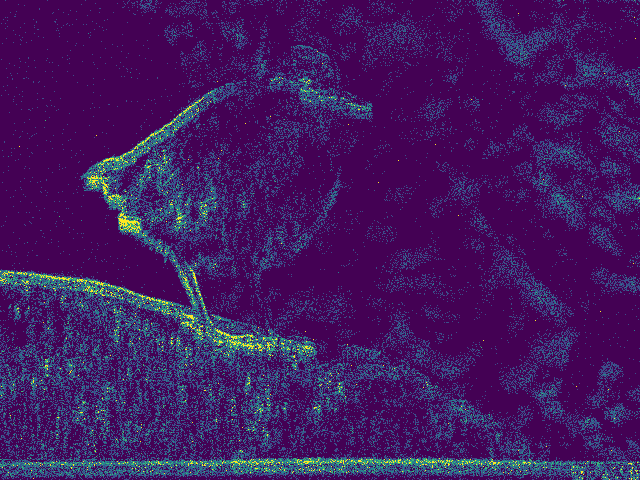

In [4]:
import tempfile
from IPython.display import Image

out = tempfile.mkdtemp()
png = ecv.export_png(frame, out, colormap="viridis")[0]
Image(filename=png)

## Next

- **[Transforms & representations](02-transforms-and-representations.ipynb)** — build a processing pipeline and feed it to PyTorch.
- **[Streaming large files](03-streaming-large-files.ipynb)** — slice a multi-gigabyte recording without loading it.